In [212]:
import matplotlib.pyplot as plt

# Глобальные настройки для всех графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18

# Глобальные переменные
FIGSIZE = (12, 8)
LINEWIDTH = 2.5
MARKERSIZE = 8
LINEWIDTH_DASHED = 3
ALPHA = 0.8

In [218]:
import pandas as pd
import numpy as np

# Load data from CSV
df = pd.read_csv('Warmup - 124M_bs=256.csv', skiprows=1)

# Extract model info and batch size from first row
model_info = "Llama 124M"
batch_size = "256"
# Muon Optimizer data - separate arrays for 64k and 128k
muon_warmup = []
muon_64k = []
muon_128k = []

for idx, row in df.iterrows():
    warmup_val = df.iloc[idx, 0]
    if pd.notna(warmup_val) and warmup_val != 'Adaptive via \nK_0, K_1, K_2 (ours)':
        try:
            warmup_num = float(str(warmup_val).replace(',', ''))
            
            # 64K data (column 1)
            if pd.notna(df.iloc[idx, 1]):
                muon_warmup.append(warmup_num)
                val_loss = float(str(df.iloc[idx, 1]).replace(',', '.'))
                muon_64k.append(val_loss)
            
            # 128K data (column 2)
            if pd.notna(df.iloc[idx, 2]):
                muon_128k.append(float(str(df.iloc[idx, 2]).replace(',', '.')))
        except (ValueError, AttributeError):
            pass

# Get "Ours" values for Muon
muon_ours_row = df[df.iloc[:, 0] == 'Adaptive via \nK_0, K_1, K_2 (ours)']
muon_ours_64k = float(str(muon_ours_row.iloc[0, 1]).replace(',', '.'))
muon_ours_128k = float(str(muon_ours_row.iloc[0, 2]).replace(',', '.'))

# Lion Optimizer data - separate arrays for 64k and 128k
lion_warmup = []
lion_64k = []
lion_warmup_128k = []
lion_128k = []

for idx, row in df.iterrows():
    warmup_val = df.iloc[idx, 0]
    if pd.notna(warmup_val) and warmup_val != 'Adaptive via \nK_0, K_1, K_2 (ours)':
        try:
            warmup_num = float(str(warmup_val).replace(',', ''))
            
            # 64K data (column 3)
            if pd.notna(df.iloc[idx, 3]):
                lion_warmup.append(warmup_num)
                lion_64k.append(float(str(df.iloc[idx, 3]).replace(',', '.')))
            
            # 128K data (column 4)
            if pd.notna(df.iloc[idx, 4]):
                lion_warmup_128k.append(warmup_num)
                lion_128k.append(float(str(df.iloc[idx, 4]).replace(',', '.')))
        except (ValueError, AttributeError):
            pass

# Get "Ours" values for Lion
lion_ours_64k = float(str(muon_ours_row.iloc[0, 3]).replace(',', '.'))
lion_ours_128k = float(str(muon_ours_row.iloc[0, 4]).replace(',', '.'))

# NormalizedSGD Optimizer data - separate arrays for 64k and 128k
nsgd_warmup = []
nsgd_64k = []
nsgd_warmup_128k = []
nsgd_128k = []

for idx, row in df.iterrows():
    warmup_val = df.iloc[idx, 0]
    if pd.notna(warmup_val) and warmup_val != 'Adaptive via \nK_0, K_1, K_2 (ours)':
        try:
            warmup_num = float(str(warmup_val).replace(',', ''))
            
            # 64K data (column 5)
            if pd.notna(df.iloc[idx, 5]):
                nsgd_warmup.append(warmup_num)
                nsgd_64k.append(float(str(df.iloc[idx, 5]).replace(',', '.')))
            
            # 128K data (column 6)
            if pd.notna(df.iloc[idx, 6]):
                nsgd_warmup_128k.append(warmup_num)
                nsgd_128k.append(float(str(df.iloc[idx, 6]).replace(',', '.')))
        except (ValueError, AttributeError):
            pass

# Get "Ours" values for NormalizedSGD
nsgd_ours_64k = float(str(muon_ours_row.iloc[0, 5]).replace(',', '.'))
nsgd_ours_128k = float(str(muon_ours_row.iloc[0, 6]).replace(',', '.'))

print(f"Model: {model_info}, Batch Size: {batch_size}")
print(f"Muon data points: 64k={len(muon_64k)}, 128k={len(muon_128k)}")
print(f"Lion data points: 64k={len(lion_64k)}, 128k={len(lion_128k)}")
print(f"NSGD data points: 64k={len(nsgd_64k)}, 128k={len(nsgd_128k)}")

Model: Llama 124M, Batch Size: 256
Muon data points: 64k=12, 128k=12
Lion data points: 64k=13, 128k=13
NSGD data points: 64k=10, 128k=10


/var/folders/kd/mxk4216x0hb7hph3jhhp3tp80000gn/T/ipykernel_1964/1813404620.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


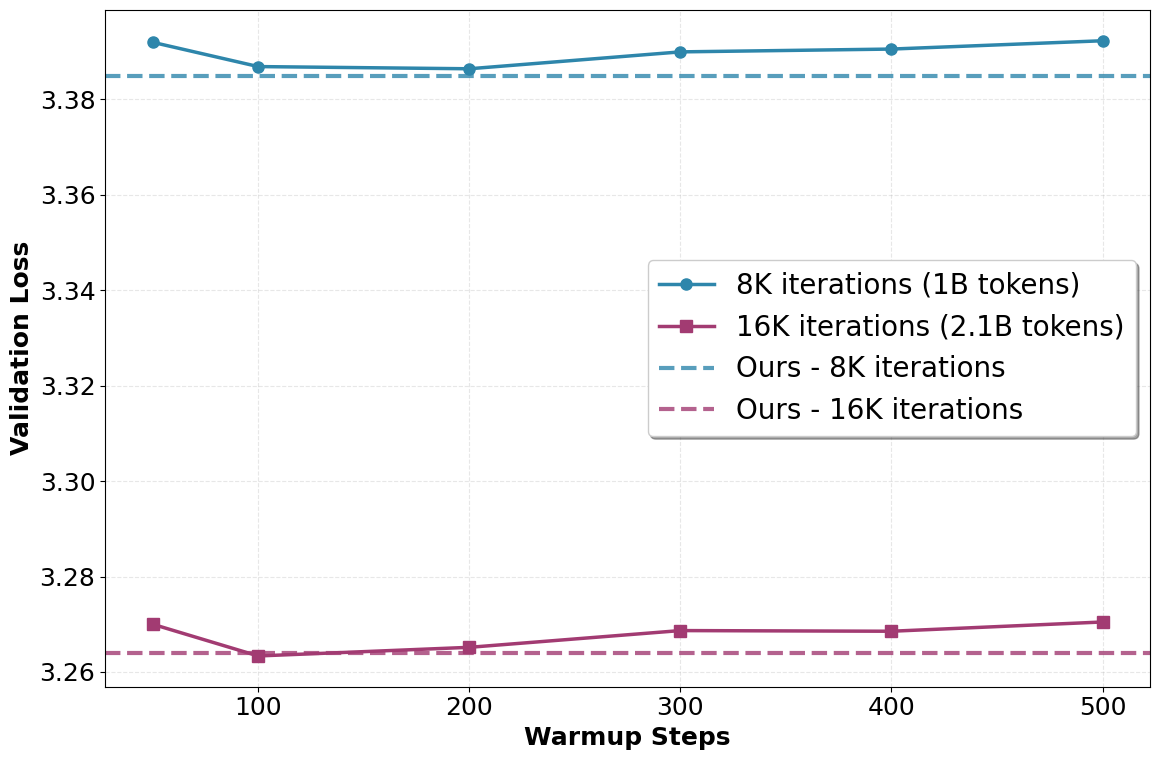

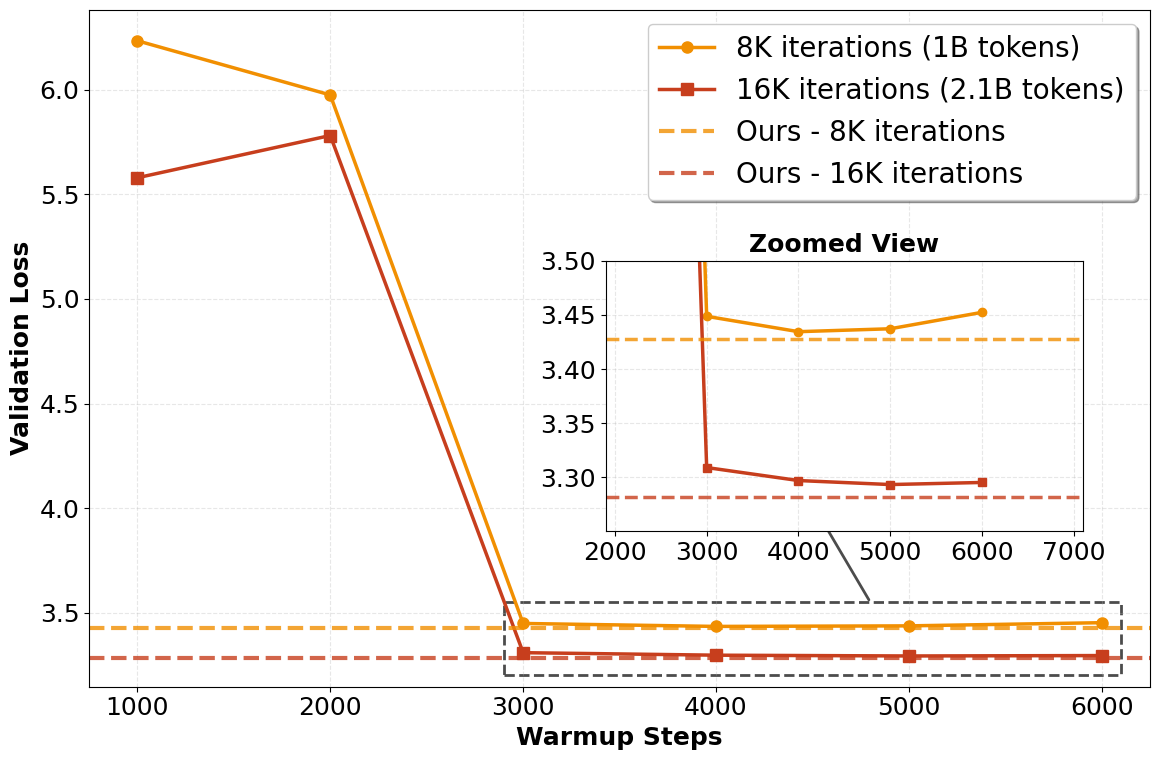

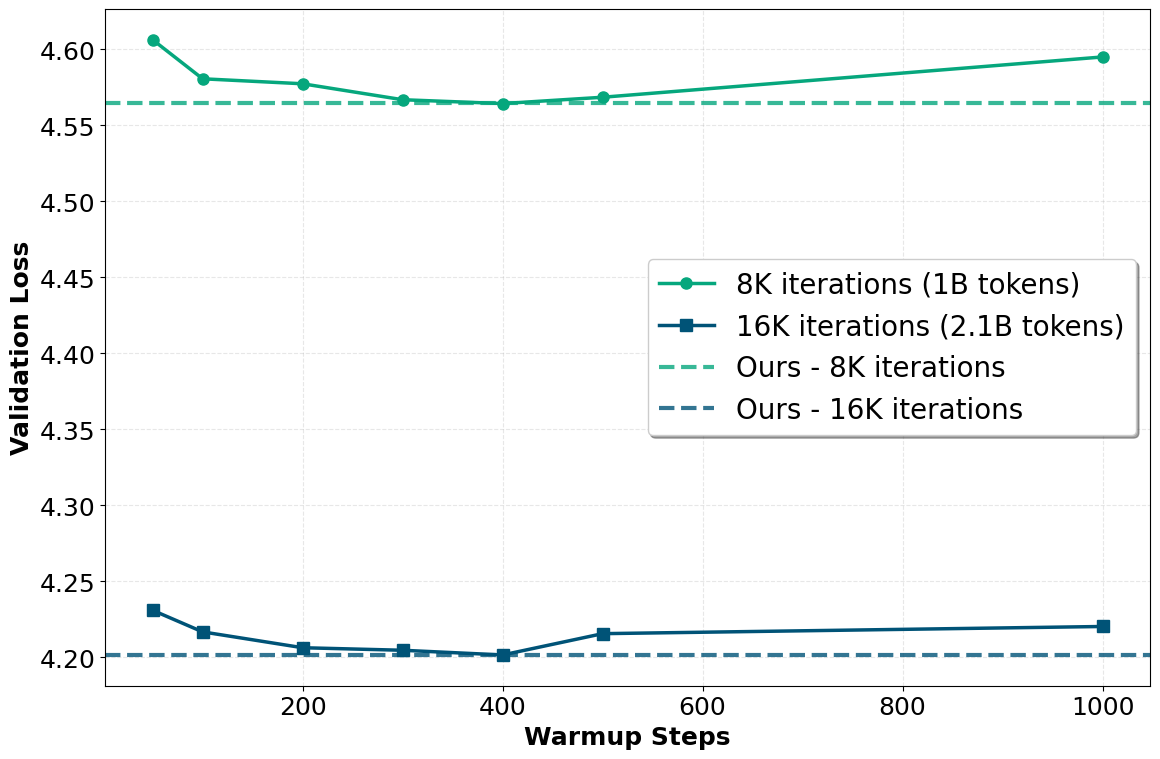

In [216]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, FancyArrowPatch

# Figure 1: Muon Optimizer
fig1, ax1 = plt.subplots(figsize=FIGSIZE)
ax1.plot(muon_warmup, muon_64k, 'o-', color='#2E86AB', label='8K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.plot(muon_warmup, muon_128k, 's-', color='#A23B72', label='16K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.axhline(y=muon_ours_64k, color='#2E86AB', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 8K iterations', alpha=ALPHA)
ax1.axhline(y=muon_ours_128k, color='#A23B72', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 16K iterations', alpha=ALPHA)

ax1.set_xlabel('Warmup Steps', fontweight='bold')
ax1.set_ylabel('Validation Loss', fontweight='bold')
# ax1.set_title(f'Muon Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
# ax1.set_xlim(0, max(muon_warmup) + 500)
plt.tight_layout()
plt.savefig(f'muon_{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 2: Lion Optimizer WITH ZOOM
fig2, ax2 = plt.subplots(figsize=FIGSIZE)
ax2.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', label='8K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', label='16K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 8K iterations', alpha=ALPHA)
ax2.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 16K iterations', alpha=ALPHA)

ax2.set_xlabel('Warmup Steps', fontweight='bold')
ax2.set_ylabel('Validation Loss', fontweight='bold')
# ax2.set_title(f'Lion Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax2.legend(loc='upper right', frameon=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='--')
# ax2.set_xlim(0, max(lion_warmup) + 500)
# ax2.set_ylim(3.3, 6.0)
# ax2.set_yticks(np.arange(3.3, 6.0, 0.5))

# Create zoomed inset
axins = inset_axes(ax2, width="45%", height="40%", 
                   bbox_to_anchor=(-0.05, -0.35, 1, 1), bbox_transform=ax2.transAxes)

# Plot the same data in the inset
axins.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', linewidth=LINEWIDTH, markersize=6)
axins.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', linewidth=LINEWIDTH, markersize=6)
axins.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)
axins.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)

# Set the zoom limits to focus on the convergence region
axins.set_xlim(1900, 7100)
axins.set_ylim(3.25, 3.50)
# axins.set_xticks(np.arange(3000, 7501, 1000))
axins.set_yticks(np.arange(3.3, 3.51, 0.05))
axins.grid(True, alpha=0.3, linestyle='--')
axins.set_title('Zoomed View', fontweight='bold')

# Add a box to show what region is zoomed
rect = Rectangle((2900, 3.2), 3200, 0.35, linewidth=2, edgecolor='black', 
                 facecolor='none', linestyle='--', alpha=0.7)
ax2.add_patch(rect)

# Draw arrow from center of top side of rectangle to center of right side of inset
arrow_prop = dict(arrowstyle='->', mutation_scale=20, linewidth=2, color='black', alpha=0.7)
ax2.annotate('', xy=(0.3, 0.5), xycoords=axins.transAxes,
             xytext=(4800, 3.55), textcoords=ax2.transData,
             arrowprops=arrow_prop)

plt.tight_layout()
plt.savefig(f'lion__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 3: NormalizedSGD Optimizer
fig3, ax3 = plt.subplots(figsize=FIGSIZE)
ax3.plot(nsgd_warmup, nsgd_64k, 'o-', color='#06A77D', label='8K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.plot(nsgd_warmup_128k, nsgd_128k, 's-', color='#005377', label='16K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.axhline(y=nsgd_ours_64k, color='#06A77D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 8K iterations', alpha=ALPHA)
ax3.axhline(y=nsgd_ours_128k, color='#005377', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 16K iterations', alpha=ALPHA)

ax3.set_xlabel('Warmup Steps', fontweight='bold')
ax3.set_ylabel('Validation Loss', fontweight='bold')
# ax3.set_title(f'NormalizedSGD Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax3.legend(loc='best', frameon=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(0, max(nsgd_warmup) + 100)
plt.tight_layout()
plt.savefig(f'normalizedsgd__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

plt.show()

/var/folders/kd/mxk4216x0hb7hph3jhhp3tp80000gn/T/ipykernel_1964/1582555822.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


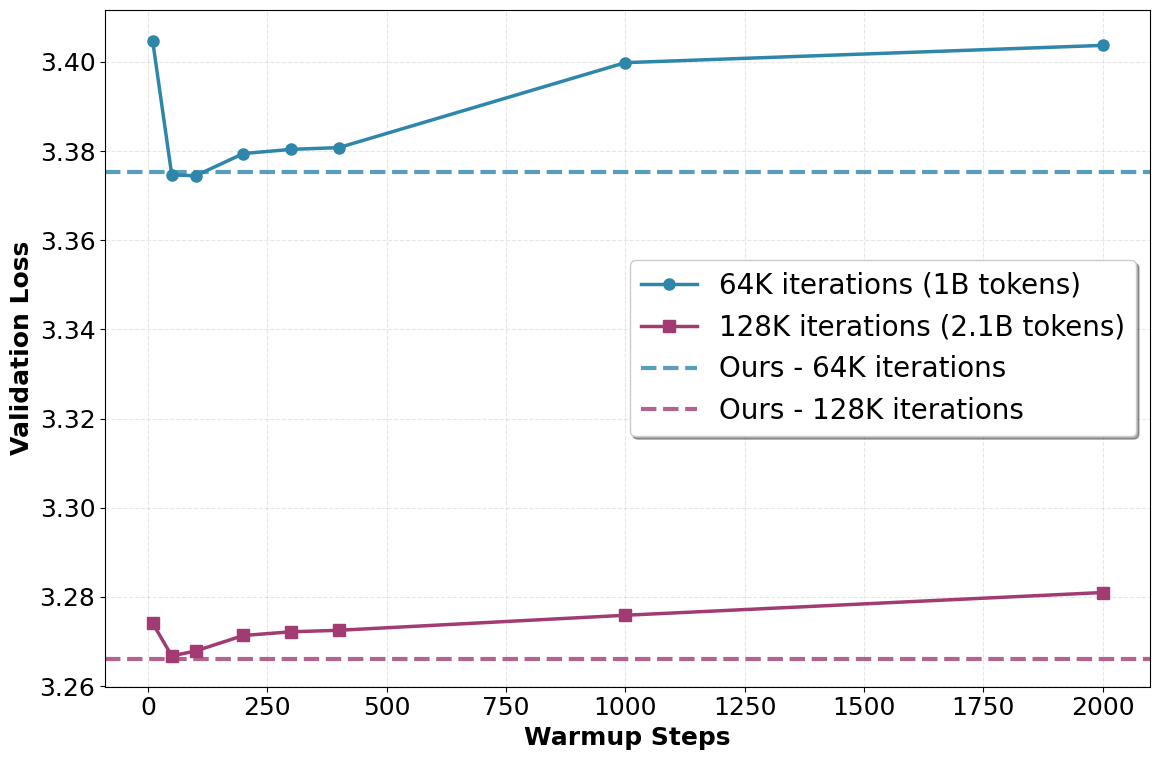

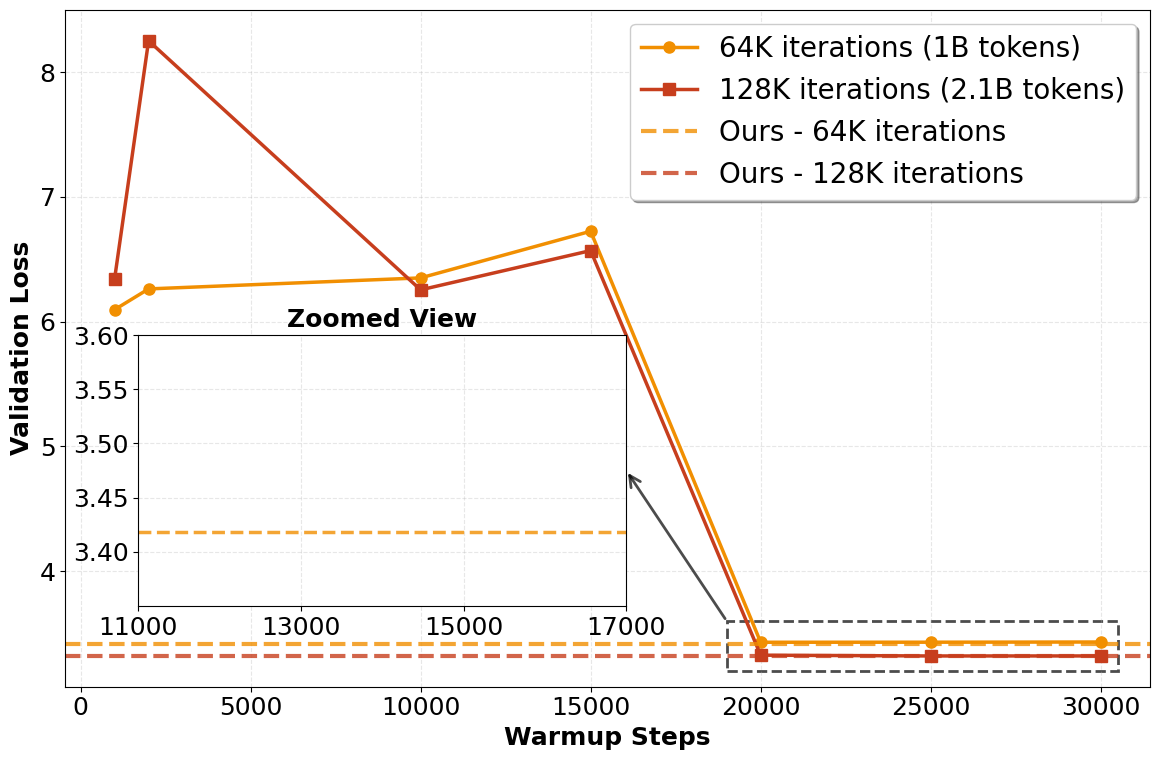

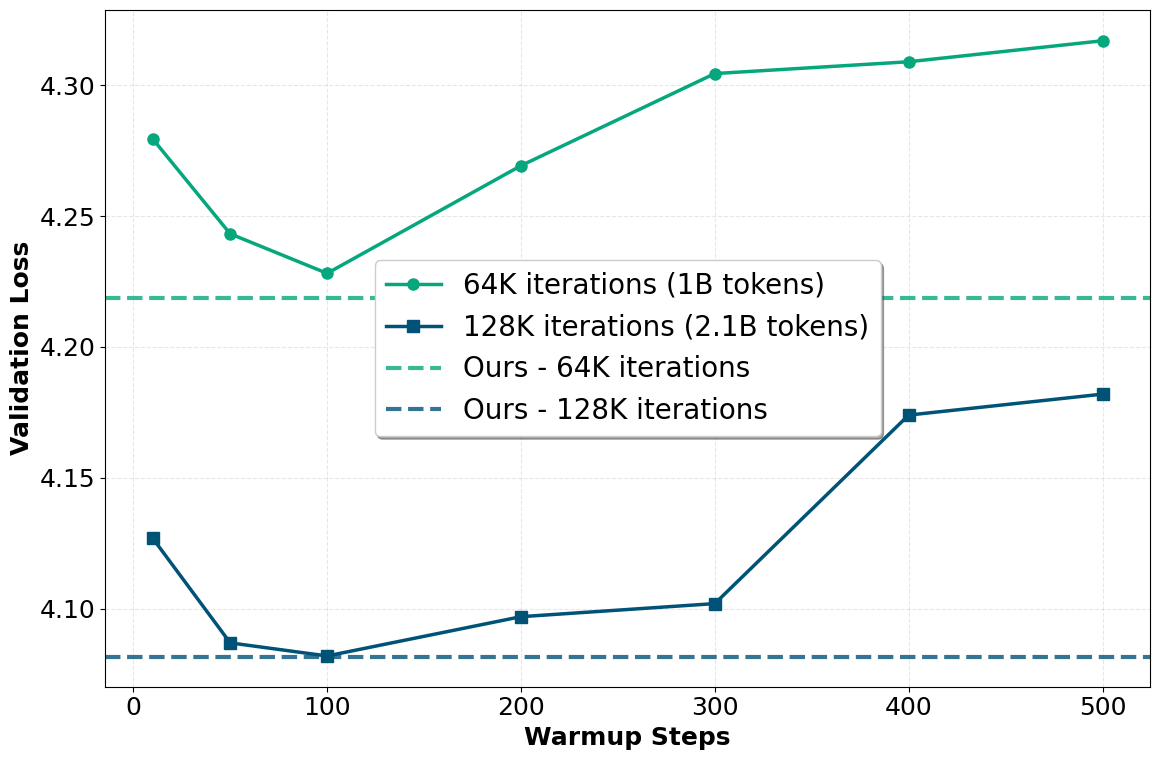

In [187]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, FancyArrowPatch

# Figure 1: Muon Optimizer
fig1, ax1 = plt.subplots(figsize=FIGSIZE)
ax1.plot(muon_warmup, muon_64k, 'o-', color='#2E86AB', label='64K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.plot(muon_warmup, muon_128k, 's-', color='#A23B72', label='128K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.axhline(y=muon_ours_64k, color='#2E86AB', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 64K iterations', alpha=ALPHA)
ax1.axhline(y=muon_ours_128k, color='#A23B72', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 128K iterations', alpha=ALPHA)

ax1.set_xlabel('Warmup Steps', fontweight='bold')
ax1.set_ylabel('Validation Loss', fontweight='bold')
# ax1.set_title(f'Muon Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
# ax1.set_xlim(0, max(muon_warmup) + 500)
plt.tight_layout()
plt.savefig(f'muon_{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 2: Lion Optimizer WITH ZOOM
fig2, ax2 = plt.subplots(figsize=FIGSIZE)
ax2.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', label='64K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', label='128K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 64K iterations', alpha=ALPHA)
ax2.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 128K iterations', alpha=ALPHA)

ax2.set_xlabel('Warmup Steps', fontweight='bold')
ax2.set_ylabel('Validation Loss', fontweight='bold')
# ax2.set_title(f'Lion Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax2.legend(loc='upper right', frameon=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='--')
# ax2.set_xlim(0, max(lion_warmup) + 1000)
# ax2.set_ylim(3.3, 8.0)

# Create zoomed inset
axins = inset_axes(ax2, width="45%", height="40%", 
                   bbox_to_anchor=(-0.47, -0.46, 1, 1), bbox_transform=ax2.transAxes)

# Plot the same data in the inset
axins.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', linewidth=LINEWIDTH, markersize=6)
axins.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', linewidth=LINEWIDTH, markersize=6)
axins.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)
axins.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)

# Set the zoom limits to focus on the convergence region
axins.set_xlim(11000, 17000)
axins.set_ylim(3.35, 3.60)
axins.set_xticks(np.arange(11000, 17001, 2000))
axins.set_yticks(np.arange(3.40, 3.61, 0.05))
axins.grid(True, alpha=0.3, linestyle='--')
axins.set_title('Zoomed View', fontweight='bold')

# Add a box to show what region is zoomed
rect = Rectangle((19000, 3.2), 11500, 0.4, linewidth=2, edgecolor='black', 
                 facecolor='none', linestyle='--', alpha=0.7)
ax2.add_patch(rect)

# Draw arrow from center of top side of rectangle to center of right side of inset
arrow_prop = dict(arrowstyle='->', mutation_scale=20, linewidth=2, color='black', alpha=0.7)
ax2.annotate('', xy=(1.0, 0.5), xycoords=axins.transAxes,
             xytext=(19000, 3.60), textcoords=ax2.transData,
             arrowprops=arrow_prop)

plt.tight_layout()
plt.savefig(f'lion__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 3: NormalizedSGD Optimizer
fig3, ax3 = plt.subplots(figsize=FIGSIZE)
ax3.plot(nsgd_warmup, nsgd_64k, 'o-', color='#06A77D', label='64K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.plot(nsgd_warmup_128k, nsgd_128k, 's-', color='#005377', label='128K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.axhline(y=nsgd_ours_64k, color='#06A77D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 64K iterations', alpha=ALPHA)
ax3.axhline(y=nsgd_ours_128k, color='#005377', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 128K iterations', alpha=ALPHA)

ax3.set_xlabel('Warmup Steps', fontweight='bold')
ax3.set_ylabel('Validation Loss', fontweight='bold')
# ax3.set_title(f'NormalizedSGD Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax3.legend(loc='best', frameon=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--')
# ax3.set_xlim(0, max(nsgd_warmup) + 50)
plt.tight_layout()
plt.savefig(f'normalizedsgd__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

plt.show()

/var/folders/kd/mxk4216x0hb7hph3jhhp3tp80000gn/T/ipykernel_1964/3725020175.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


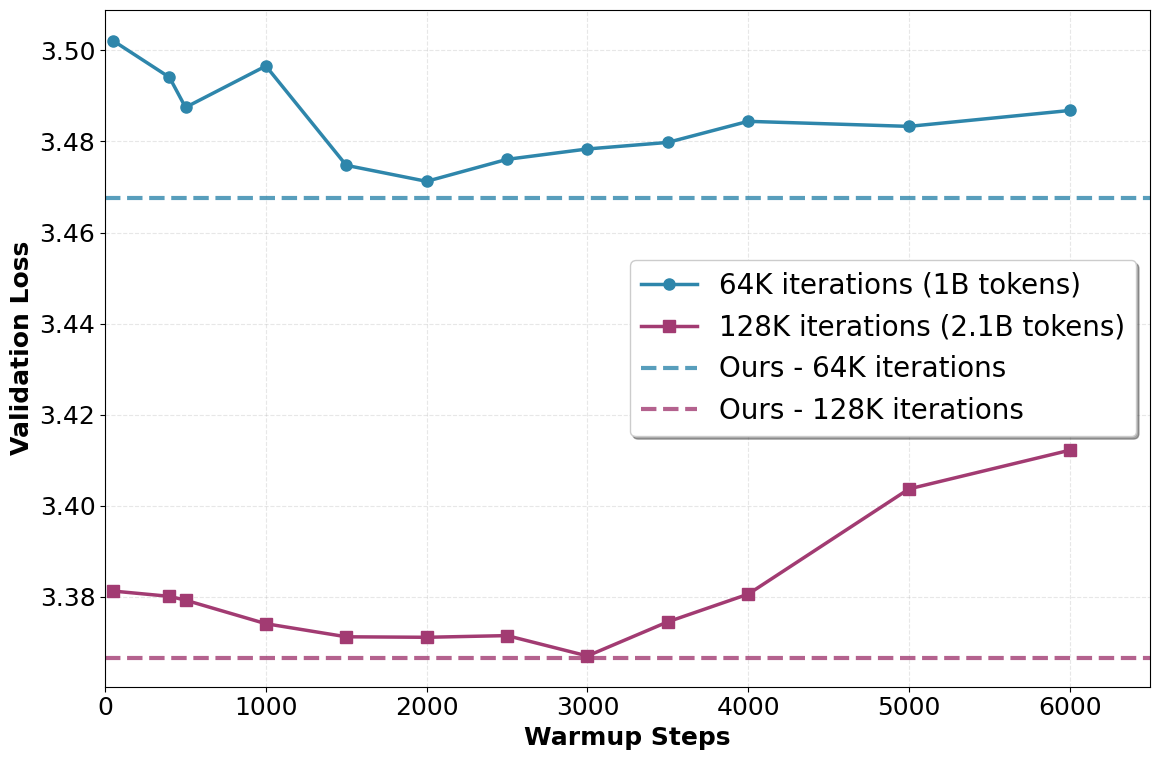

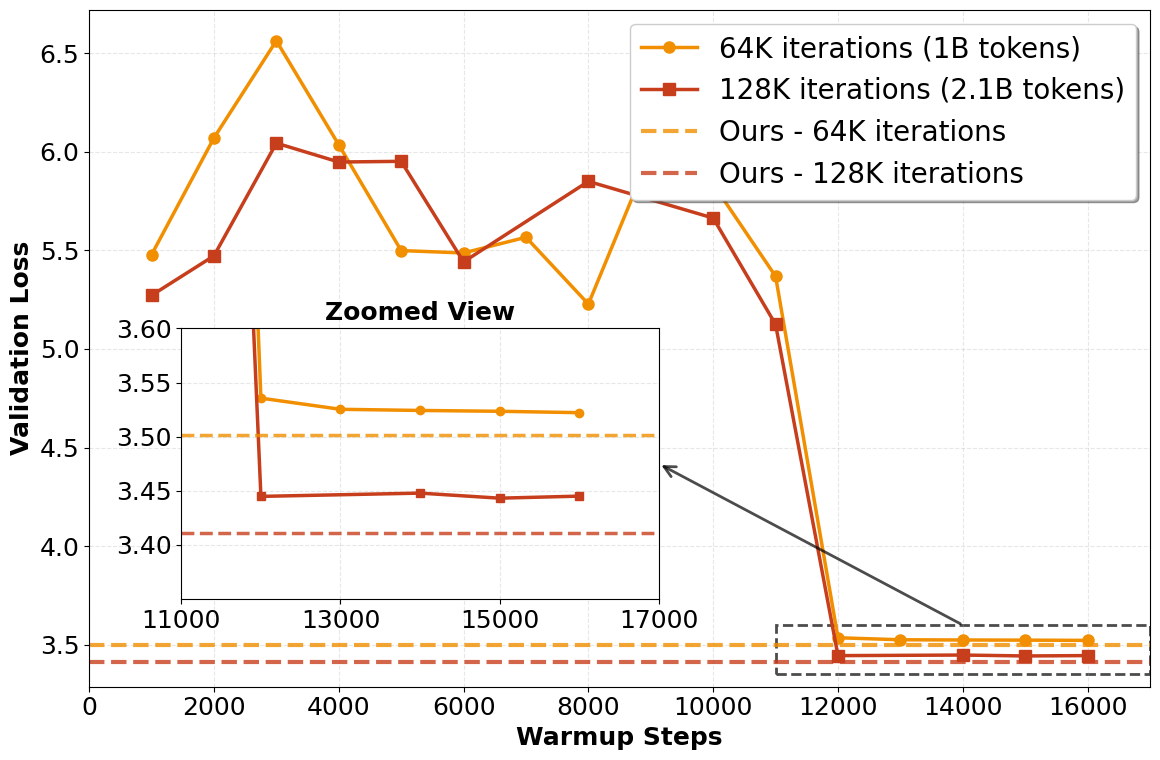

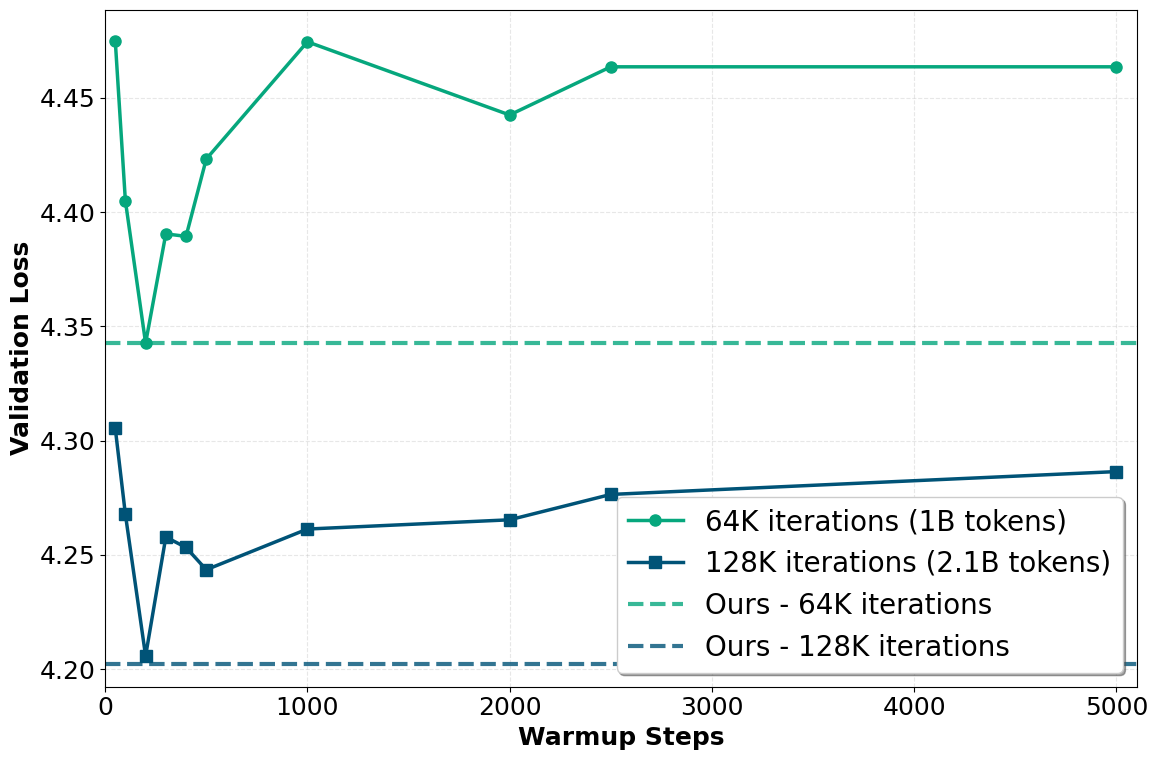

In [20]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, FancyArrowPatch

# Figure 1: Muon Optimizer
fig1, ax1 = plt.subplots(figsize=FIGSIZE)
ax1.plot(muon_warmup, muon_64k, 'o-', color='#2E86AB', label='64K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.plot(muon_warmup, muon_128k, 's-', color='#A23B72', label='128K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.axhline(y=muon_ours_64k, color='#2E86AB', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 64K iterations', alpha=ALPHA)
ax1.axhline(y=muon_ours_128k, color='#A23B72', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 128K iterations', alpha=ALPHA)

ax1.set_xlabel('Warmup Steps', fontweight='bold')
ax1.set_ylabel('Validation Loss', fontweight='bold')
# ax1.set_title(f'Muon Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, max(muon_warmup) + 500)
plt.tight_layout()
plt.savefig(f'muon_{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 2: Lion Optimizer WITH ZOOM
fig2, ax2 = plt.subplots(figsize=FIGSIZE)
ax2.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', label='64K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', label='128K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 64K iterations', alpha=ALPHA)
ax2.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 128K iterations', alpha=ALPHA)

ax2.set_xlabel('Warmup Steps', fontweight='bold')
ax2.set_ylabel('Validation Loss', fontweight='bold')
# ax2.set_title(f'Lion Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax2.legend(loc='upper right', frameon=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, max(lion_warmup) + 1000)
# ax2.set_ylim(3.3, 8.0)

# Create zoomed inset
axins = inset_axes(ax2, width="45%", height="40%", 
                   bbox_to_anchor=(-0.45, -0.45, 1, 1), bbox_transform=ax2.transAxes)

# Plot the same data in the inset
axins.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', linewidth=LINEWIDTH, markersize=6)
axins.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', linewidth=LINEWIDTH, markersize=6)
axins.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)
axins.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)

# Set the zoom limits to focus on the convergence region
axins.set_xlim(11000, 17000)
axins.set_ylim(3.35, 3.60)
axins.set_xticks(np.arange(11000, 17001, 2000))
axins.set_yticks(np.arange(3.40, 3.61, 0.05))
axins.grid(True, alpha=0.3, linestyle='--')
axins.set_title('Zoomed View', fontweight='bold')

# Add a box to show what region is zoomed
rect = Rectangle((11000, 3.35), 6000, 0.25, linewidth=2, edgecolor='black', 
                 facecolor='none', linestyle='--', alpha=0.7)
ax2.add_patch(rect)

# Draw arrow from center of top side of rectangle to center of right side of inset
arrow_prop = dict(arrowstyle='->', mutation_scale=20, linewidth=2, color='black', alpha=0.7)
ax2.annotate('', xy=(1.0, 0.5), xycoords=axins.transAxes,
             xytext=(14000, 3.60), textcoords=ax2.transData,
             arrowprops=arrow_prop)

plt.tight_layout()
plt.savefig(f'lion__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 3: NormalizedSGD Optimizer
fig3, ax3 = plt.subplots(figsize=FIGSIZE)
ax3.plot(nsgd_warmup, nsgd_64k, 'o-', color='#06A77D', label='64K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.plot(nsgd_warmup_128k, nsgd_128k, 's-', color='#005377', label='128K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.axhline(y=nsgd_ours_64k, color='#06A77D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 64K iterations', alpha=ALPHA)
ax3.axhline(y=nsgd_ours_128k, color='#005377', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 128K iterations', alpha=ALPHA)

ax3.set_xlabel('Warmup Steps', fontweight='bold')
ax3.set_ylabel('Validation Loss', fontweight='bold')
# ax3.set_title(f'NormalizedSGD Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax3.legend(loc='best', frameon=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(0, max(nsgd_warmup) + 100)
plt.tight_layout()
plt.savefig(f'normalizedsgd__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

plt.show()

/var/folders/kd/mxk4216x0hb7hph3jhhp3tp80000gn/T/ipykernel_1964/1437552858.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


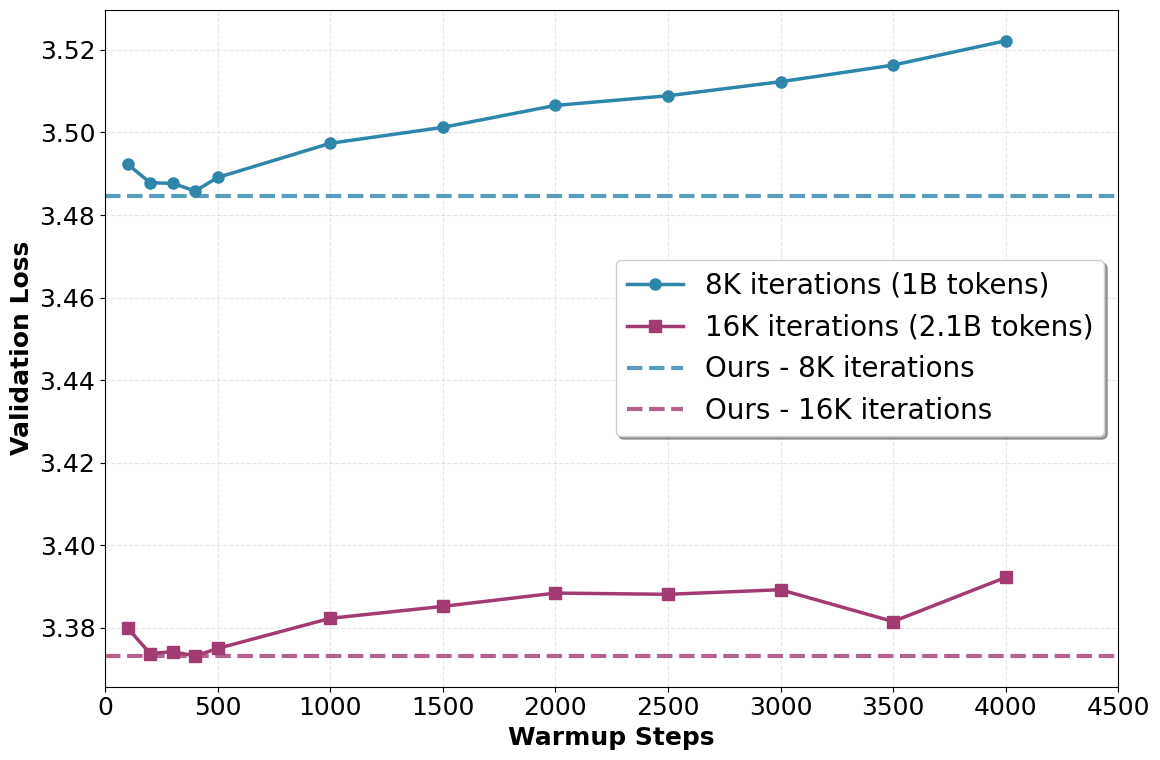

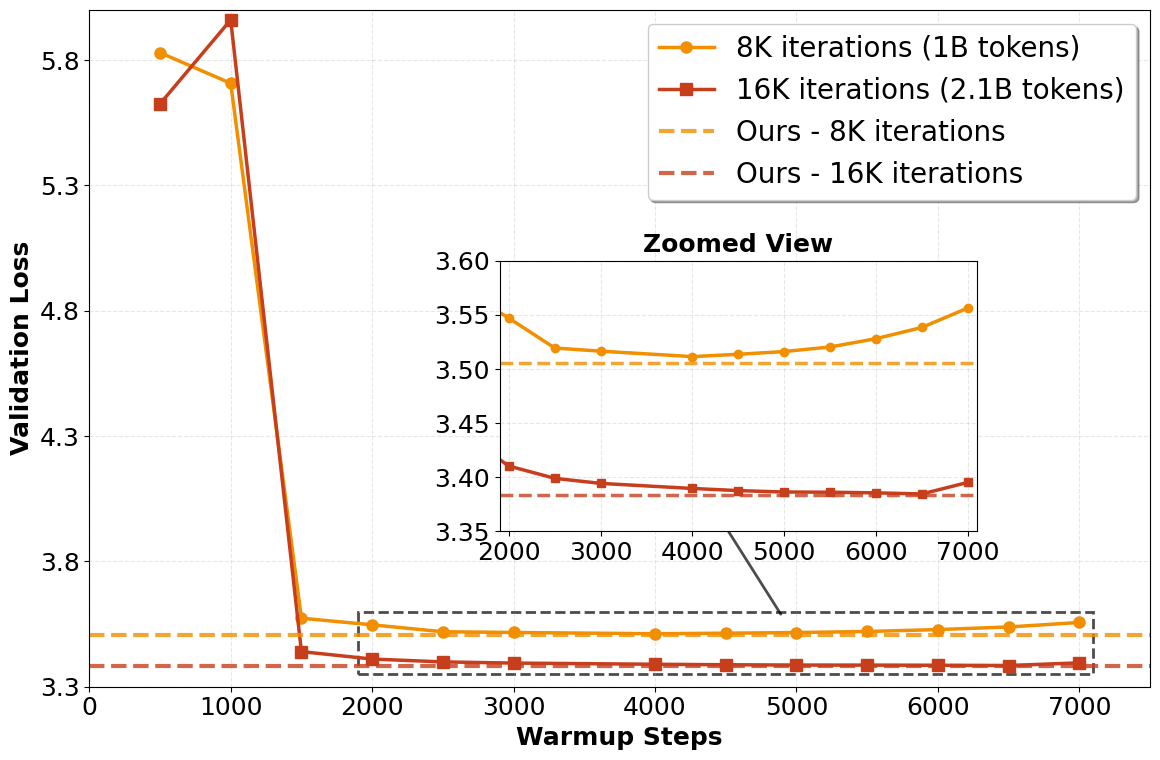

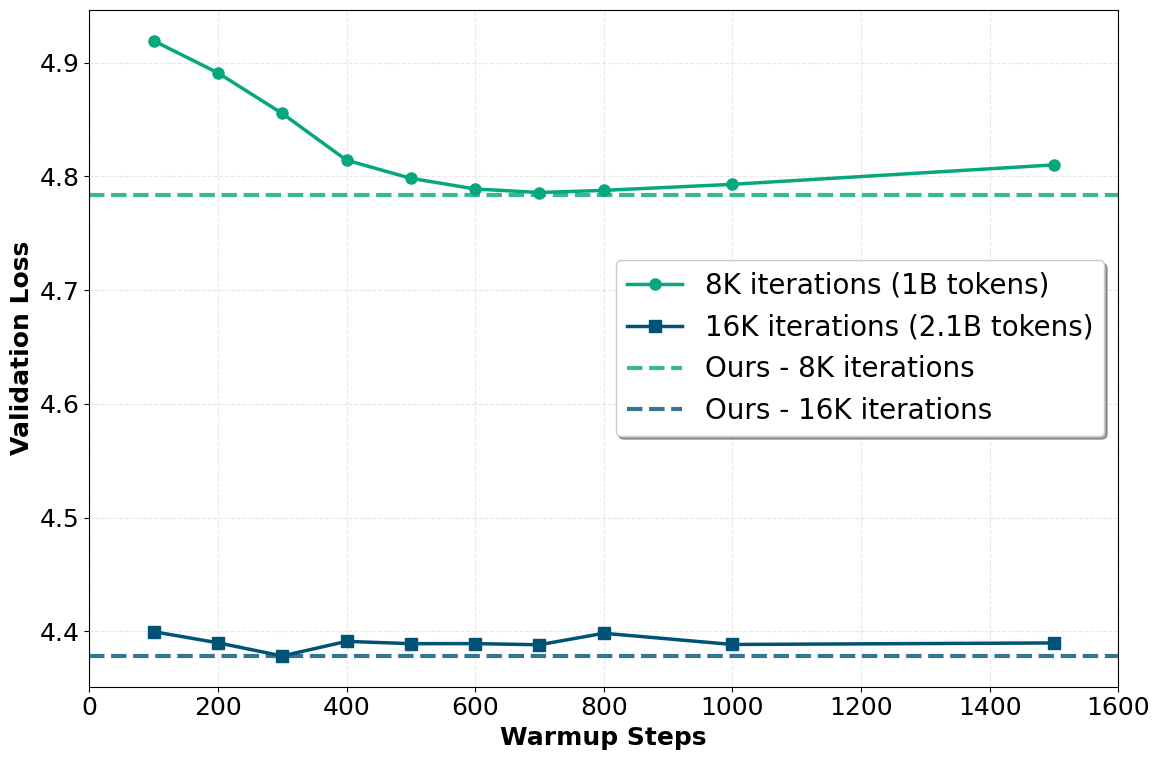

In [220]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, FancyArrowPatch

# Figure 1: Muon Optimizer
fig1, ax1 = plt.subplots(figsize=FIGSIZE)
ax1.plot(muon_warmup, muon_64k, 'o-', color='#2E86AB', label='8K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.plot(muon_warmup, muon_128k, 's-', color='#A23B72', label='16K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax1.axhline(y=muon_ours_64k, color='#2E86AB', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 8K iterations', alpha=ALPHA)
ax1.axhline(y=muon_ours_128k, color='#A23B72', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 16K iterations', alpha=ALPHA)

ax1.set_xlabel('Warmup Steps', fontweight='bold')
ax1.set_ylabel('Validation Loss', fontweight='bold')
# ax1.set_title(f'Muon Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, max(muon_warmup) + 500)
plt.tight_layout()
plt.savefig(f'muon_{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 2: Lion Optimizer WITH ZOOM
fig2, ax2 = plt.subplots(figsize=FIGSIZE)
ax2.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', label='8K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', label='16K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax2.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 8K iterations', alpha=ALPHA)
ax2.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 16K iterations', alpha=ALPHA)

ax2.set_xlabel('Warmup Steps', fontweight='bold')
ax2.set_ylabel('Validation Loss', fontweight='bold')
# ax2.set_title(f'Lion Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax2.legend(loc='upper right', frameon=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, max(lion_warmup) + 500)
ax2.set_ylim(3.3, 6.0)
ax2.set_yticks(np.arange(3.3, 6.0, 0.5))

# Create zoomed inset
axins = inset_axes(ax2, width="45%", height="40%", 
                   bbox_to_anchor=(-0.15, -0.35, 1, 1), bbox_transform=ax2.transAxes)

# Plot the same data in the inset
axins.plot(lion_warmup, lion_64k, 'o-', color='#F18F01', linewidth=LINEWIDTH, markersize=6)
axins.plot(lion_warmup_128k, lion_128k, 's-', color='#C73E1D', linewidth=LINEWIDTH, markersize=6)
axins.axhline(y=lion_ours_64k, color='#F18F01', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)
axins.axhline(y=lion_ours_128k, color='#C73E1D', linestyle='--', linewidth=LINEWIDTH, alpha=ALPHA)

# Set the zoom limits to focus on the convergence region
axins.set_xlim(1900, 7100)
axins.set_ylim(3.35, 3.60)
axins.set_xticks(np.arange(2000, 7501, 1000))
axins.set_yticks(np.arange(3.35, 3.61, 0.05))
axins.grid(True, alpha=0.3, linestyle='--')
axins.set_title('Zoomed View', fontweight='bold')

# Add a box to show what region is zoomed
rect = Rectangle((1900, 3.35), 5200, 0.25, linewidth=2, edgecolor='black', 
                 facecolor='none', linestyle='--', alpha=0.7)
ax2.add_patch(rect)

# Draw arrow from center of top side of rectangle to center of right side of inset
arrow_prop = dict(arrowstyle='->', mutation_scale=20, linewidth=2, color='black', alpha=0.7)
ax2.annotate('', xy=(0.3, 0.5), xycoords=axins.transAxes,
             xytext=(4900, 3.58), textcoords=ax2.transData,
             arrowprops=arrow_prop)

plt.tight_layout()
plt.savefig(f'lion__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

# Figure 3: NormalizedSGD Optimizer
fig3, ax3 = plt.subplots(figsize=FIGSIZE)
ax3.plot(nsgd_warmup, nsgd_64k, 'o-', color='#06A77D', label='8K iterations (1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.plot(nsgd_warmup_128k, nsgd_128k, 's-', color='#005377', label='16K iterations (2.1B tokens)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax3.axhline(y=nsgd_ours_64k, color='#06A77D', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 8K iterations', alpha=ALPHA)
ax3.axhline(y=nsgd_ours_128k, color='#005377', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Ours - 16K iterations', alpha=ALPHA)

ax3.set_xlabel('Warmup Steps', fontweight='bold')
ax3.set_ylabel('Validation Loss', fontweight='bold')
# ax3.set_title(f'NormalizedSGD Optimizer: Warmup Steps vs Validation Loss\n{model_info}, Batch Size = {batch_size}', fontweight='bold')
ax3.legend(loc='best', frameon=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(0, max(nsgd_warmup) + 100)
plt.tight_layout()
plt.savefig(f'normalizedsgd__{model_info}_bs={batch_size}.pdf', bbox_inches='tight')

plt.show()

## f star ablation

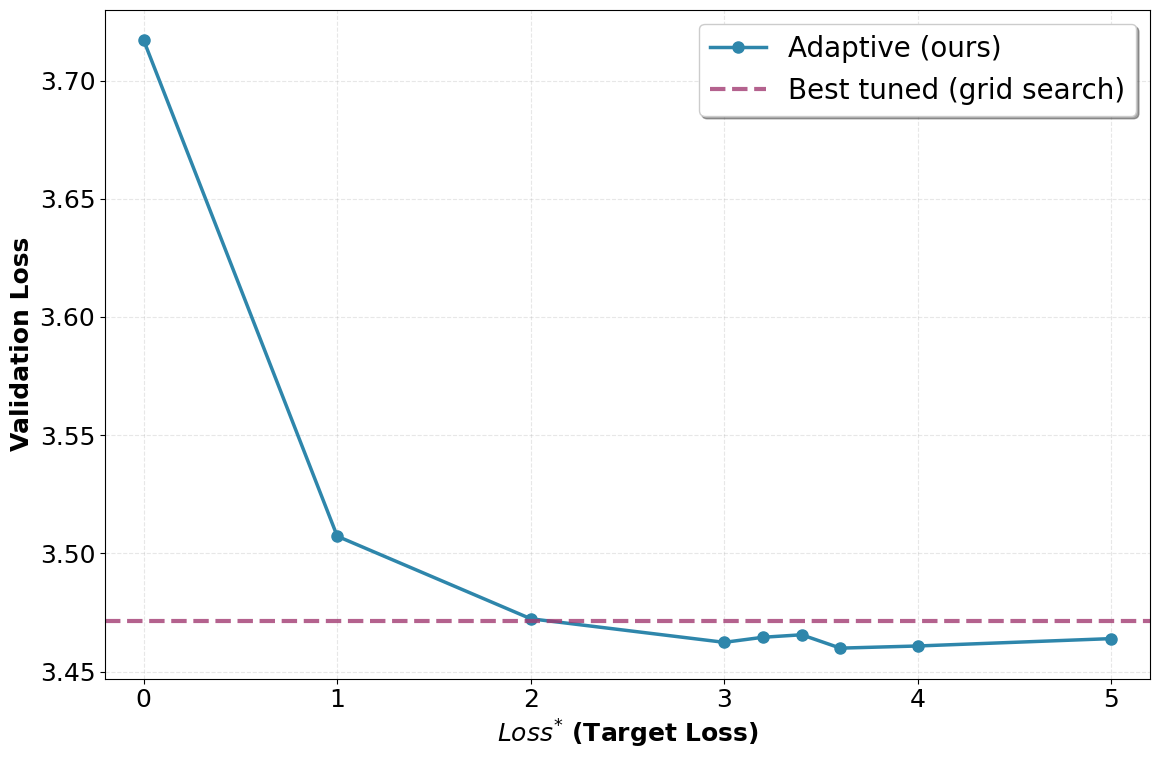

In [224]:
muon_fstar = [0, 1, 2, 3, 3.2, 3.4, 3.6, 4.0, 5.0]
muon_val = [3.71703, 3.50725, 3.47233, 3.46235, 3.4645, 3.46555, 3.4599, 3.46081, 3.46393]
muon_best_grid = 3.47124

fig4, ax4 = plt.subplots(figsize=FIGSIZE)
ax4.plot(muon_fstar, muon_val, 'o-', color='#2E86AB', label='Adaptive (ours)', linewidth=LINEWIDTH, markersize=MARKERSIZE)
ax4.axhline(y=muon_best_grid, color='#A23B72', linestyle='--', linewidth=LINEWIDTH_DASHED, label='Best tuned (grid search)', alpha=ALPHA)
ax4.set_xlabel(r'$Loss^{*}$ (Target Loss)', fontweight='bold')
ax4.set_ylabel('Validation Loss', fontweight='bold')
# ax4.set_title(r'Ablation on the $f^*$', fontweight='bold')
ax4.legend(loc='best', frameon=True, shadow=True)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(min(muon_fstar)-0.2, max(muon_fstar) + 0.2)
plt.tight_layout()
plt.savefig(f'abl_muon.pdf', bbox_inches='tight')

## warmup steps 

In [13]:
import matplotlib.pyplot as plt

# Глобальные настройки для всех графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18

# Глобальные переменные
FIGSIZE = (12, 8)
LINEWIDTH = 2.5
MARKERSIZE = 8
LINEWIDTH_DASHED = 3
ALPHA = 0.8

Total data points: 10114
Step range: 3 to 64554
LR range: 1.00e-07 to 1.00e-03

Key points:
Start: step=3, lr=1.00e-05
Max ($\Delta^\star$): step=11972, lr=1.00e-03
Warmup end: step=11972


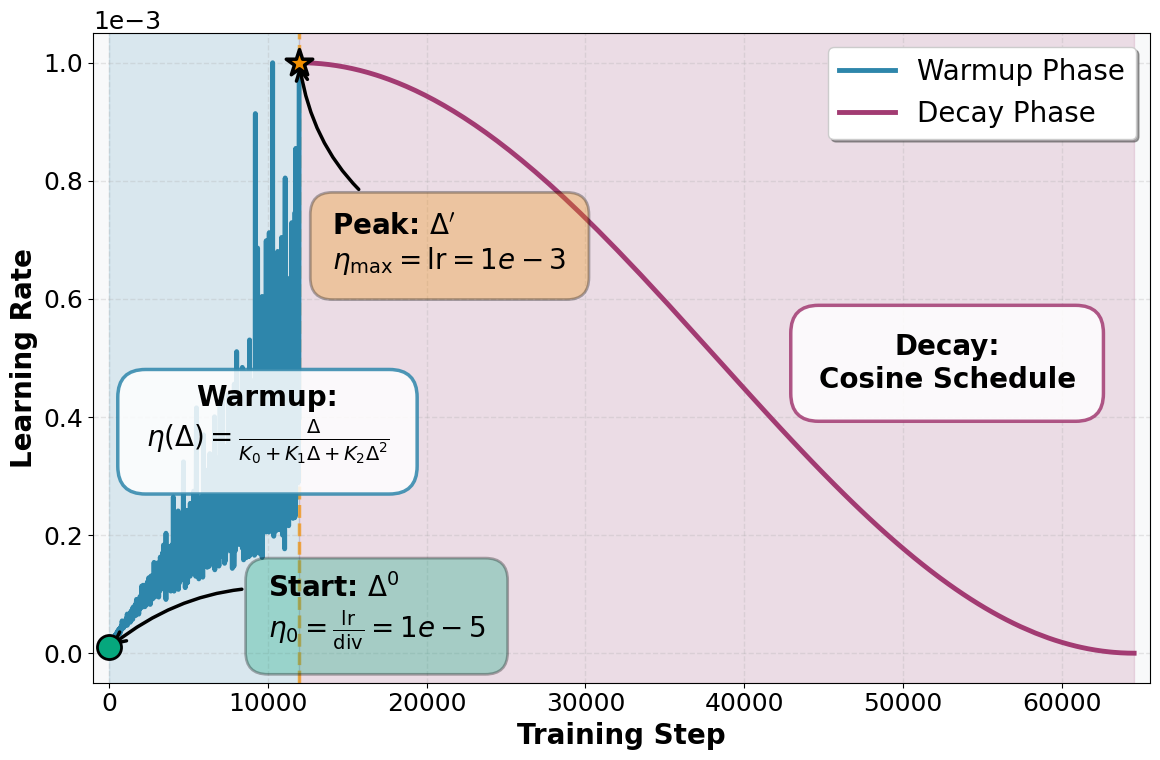

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Read the CSV file
df = pd.read_csv('wandb_export_2026-01-14T12_28_18.956+03_00.csv')

# Extract step and lr columns (using the main lr column, not MIN/MAX)
steps = df.iloc[:, 1].values  # step column
lr_values = df.iloc[:, 4].values  # lr column

# Convert to numeric in case of any issues
steps = pd.to_numeric(steps, errors='coerce')
lr_values = pd.to_numeric(lr_values, errors='coerce')

# Remove any NaN values
mask = ~np.isnan(steps) & ~np.isnan(lr_values)
steps = steps[mask]
lr_values = lr_values[mask]

print(f"Total data points: {len(steps)}")
print(f"Step range: {steps.min()} to {steps.max()}")
print(f"LR range: {lr_values.min():.2e} to {lr_values.max():.2e}")

# Find key points
idx_start = 0
idx_max = np.argmax(lr_values)
step_max = steps[idx_max]
lr_max = lr_values[idx_max]
lr_start = lr_values[idx_start]
step_start = steps[idx_start]

# Estimate where warmup ends (where lr reaches ~95% of max for the first time)
warmup_threshold = lr_max
idx_warmup_end = np.where(lr_values >= warmup_threshold)[0]
if len(idx_warmup_end) > 0:
    idx_warmup_end = idx_warmup_end[0]
else:
    idx_warmup_end = idx_max

step_warmup_end = steps[idx_warmup_end]

print(f"\nKey points:")
print(f"Start: step={step_start}, lr={lr_start:.2e}")
print(fr"Max ($\Delta^\star$): step={step_max}, lr={lr_max:.2e}")
print(f"Warmup end: step={step_warmup_end}")

# Create publication-quality figure
fig, ax = plt.subplots(figsize=FIGSIZE)

# Plot the learning rate curve with a gradient color effect
# Split into warmup and decay phases
warmup_mask = steps <= step_max
decay_mask = steps > step_max

# Plot warmup phase
ax.plot(steps[warmup_mask], lr_values[warmup_mask], 
        linewidth=3.5, color='#2E86AB', label='Warmup Phase', zorder=3)

# Plot decay phase  
ax.plot(steps[decay_mask], lr_values[decay_mask], 
        linewidth=3.5, color='#A23B72', label='Decay Phase', zorder=3)

# 1. Mark the initial point
ax.scatter(step_start, lr_start, s=300, color='#06A77D', 
           edgecolors='black', linewidths=2, zorder=5, marker='o')
ax.annotate(f'Start: $\Delta^0$\n$\eta_0 = \\frac{{\\mathrm{{lr}}}}{{\\mathrm{{div}}}}= 1e-5$',
            xy=(step_start, lr_start), xytext=(10000, lr_start + 0.000015),
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#06A77D', alpha=0.3, edgecolor='black', linewidth=2),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='black', connectionstyle='arc3,rad=0.3'))

# 2. Highlight warmup region with shading
ax.axvspan(step_start, step_warmup_end, alpha=0.15, color='#2E86AB', zorder=1)
ax.text(step_warmup_end / 1.2, lr_max * 0.35, 'Warmup:\n$\eta(\Delta)=\\frac{\\Delta}{K_0+K_1\\Delta+K_2\\Delta^2}$',
        fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=1', facecolor='white', alpha=0.85, edgecolor='#2E86AB', linewidth=2.5))

# 3. Mark the maximum point (Δ*)
ax.scatter(step_max, lr_max, s=400, color='#F18F01', 
           edgecolors='black', linewidths=2.5, zorder=5, marker='*')
ax.annotate(f'Peak: $\\Delta\'$\n$\\eta_{{\\mathrm{{max}}}} = \\mathrm{{lr}} = 1e-3$',#\nstep = {step_max}
            xy=(step_max, lr_max), xytext=(step_max + 2100, lr_max - 0.00035),
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F18F01', alpha=0.3, edgecolor='black', linewidth=2),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='black', connectionstyle='arc3,rad=-0.3'))

# 4. Highlight decay region
ax.axvspan(step_max, steps[-1], alpha=0.15, color='#A23B72', zorder=1)
decay_mid = (step_max + steps[-1]) / 1.45
ax.text(decay_mid, lr_max * 0.45, 'Decay:\nCosine Schedule',
        fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=1', facecolor='white', alpha=0.85, edgecolor='#A23B72', linewidth=2.5))

# Draw vertical dashed line at Δ*
ax.axvline(x=step_max, color='#F18F01', linestyle='--', linewidth=2.5, alpha=0.7, zorder=2)

# Styling
ax.set_xlabel('Training Step', fontweight='bold', fontsize=20)
ax.set_ylabel('Learning Rate', fontweight='bold', fontsize=20)
# ax.set_title('Learning Rate Schedule: Warmup and Decay\n(Lion Optimizer on FineWeb)', 
#              fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.legend(loc='upper right', frameon=True, shadow=True, fancybox=True)

# Set y-axis to scientific notation
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax.set_xlim(-1000, steps[-1] + 1000)
# Add a subtle background color
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig('lr_schedule.pdf', bbox_inches='tight', facecolor='white')
plt.show()

## Synthetic Learning Rate Schedule

Total iterations: 20000
Step range: 1 to 20000
LR range: 1.00e-03 to 1.58e+00

Key points:
Start: t=1, η=1.00e-03
Max (Δ*): t=3162, η=1.58e+00


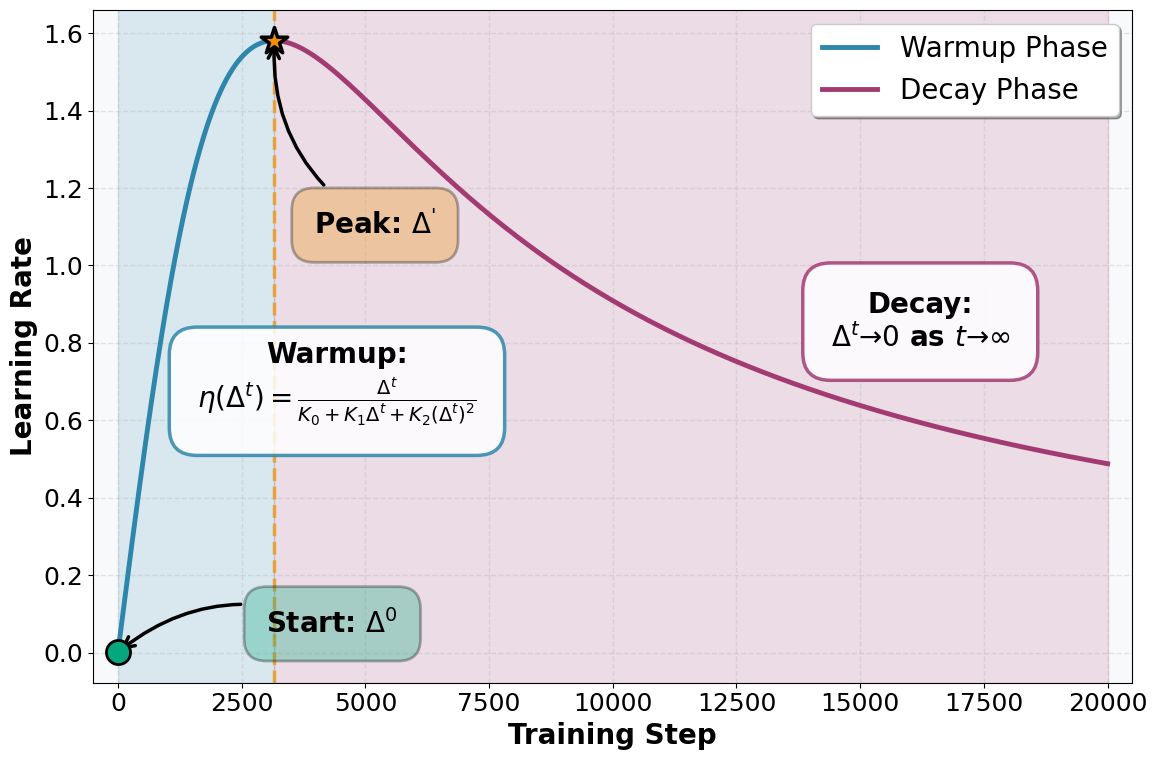

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic data parameters
t = np.arange(1, 20001)  # iterations from 1 to 20000
Delta_t = 1 / t  # Δ^t = 1/t

# Learning rate parameters (tune these for good visualization)
K_0 = 1e-4
K_1 = 0
K_2 = 1000

# Learning rate formula: η(Δ) = Δ^t / (K_0 + K_1 * Δ^t + K_2 * (Δ^t)^2)
eta = Delta_t / (K_0 + K_1 * Delta_t + K_2 * Delta_t**2)

print(f"Total iterations: {len(t)}")
print(f"Step range: {t.min()} to {t.max()}")
print(f"LR range: {eta.min():.2e} to {eta.max():.2e}")

# Find key points
idx_start = 0
idx_max = np.argmax(eta)
t_max = t[idx_max]
eta_max = eta[idx_max]
eta_start = eta[idx_start]
t_start = t[idx_start]

print(f"\nKey points:")
print(f"Start: t={t_start}, η={eta_start:.2e}")
print(f"Max (Δ*): t={t_max}, η={eta_max:.2e}")

# Create figure
fig, ax = plt.subplots(figsize=FIGSIZE)

# Split into warmup and decay phases
warmup_mask = t <= t_max
decay_mask = t > t_max

# Plot warmup phase
ax.plot(t[warmup_mask], eta[warmup_mask], 
        linewidth=3.5, color='#2E86AB', label='Warmup Phase', zorder=3)

# Plot decay phase  
ax.plot(t[decay_mask], eta[decay_mask], 
        linewidth=3.5, color='#A23B72', label='Decay Phase', zorder=3)

# Mark the initial point
ax.scatter(t_start, eta_start, s=300, color='#06A77D', 
           edgecolors='black', linewidths=2, zorder=5, marker='o')
ax.annotate(f'Start: $\Delta^0$',
            xy=(t_start, eta_start), xytext=(3000, eta_start + 0.05),
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#06A77D', alpha=0.3, edgecolor='black', linewidth=2),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='black', connectionstyle='arc3,rad=0.3'))

# Highlight warmup region
ax.axvspan(t_start, t_max, alpha=0.15, color='#2E86AB', zorder=1)
ax.text(t_max*1.4, eta_max * 0.4, 'Warmup:\n$\eta(\Delta^t)=\\frac{\Delta^t}{K_0+K_1\Delta^t+K_2(\Delta^t)^2}$',
        fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=1', facecolor='white', alpha=0.85, edgecolor='#2E86AB', linewidth=2.5))

# Mark the maximum point
ax.scatter(t_max, eta_max, s=400, color='#F18F01', 
           edgecolors='black', linewidths=2.5, zorder=5, marker='*')
ax.annotate(f'Peak: $\\Delta^\'$',
            xy=(t_max, eta_max), xytext=(t_max + 800, eta_max - 0.5),
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F18F01', alpha=0.3, edgecolor='black', linewidth=2),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='black', connectionstyle='arc3,rad=-0.3'))

# Highlight decay region
ax.axvspan(t_max, t[-1], alpha=0.15, color='#A23B72', zorder=1)
decay_mid = (t_max + t[-1]) / 1.5
ax.text(decay_mid*1.05, eta_max * 0.5, 'Decay:\n$\\Delta^t \\to 0$ as $t \\to \infty$',
        fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=1', facecolor='white', alpha=0.85, edgecolor='#A23B72', linewidth=2.5))

# Draw vertical dashed line at peak
ax.axvline(x=t_max, color='#F18F01', linestyle='--', linewidth=2.5, alpha=0.7, zorder=2)

# Styling
ax.set_xlabel('Training Step', fontweight='bold', fontsize=20)
ax.set_ylabel('Learning Rate', fontweight='bold', fontsize=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.legend(loc='upper right', frameon=True, shadow=True, fancybox=True)

# Set y-axis to scientific notation
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax.set_xlim(-500, t[-1] + 500)
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig('synthetic_lr_schedule.pdf', bbox_inches='tight', facecolor='white')
plt.show()